In [1]:
using Pkg

println(pwd())

Pkg.activate(".")
Pkg.develop(path="..")

using MiniAutoDiff

/home/mraeth@ipp.mpg.de/misc/MiniAutoDiff/MiniAutoDiff/bin


  Activating project at `~/misc/MiniAutoDiff/MiniAutoDiff/bin`
   Resolving package versions...
     Project No packages added to or removed from `~/misc/MiniAutoDiff/MiniAutoDiff/bin/Project.toml`
    Manifest No packages added to or removed from `~/misc/MiniAutoDiff/MiniAutoDiff/bin/Manifest.toml`

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [2]:
a = Variable(5.)
b = Variable(3.)
c = Variable(2.)

function f(a, b, c)
    return a * exp(c*b) + c*c*a
end

MiniAutoDiff.diff(f(a, b, c))


delta = Variable(0.00001)
dfda= (f(a + delta, b, c).value - f(a, b, c).value)/delta.value
println("Autodiff df/da=", a.grad)
println("Numerical df/da=", dfda)

dfda= (f(a, b + delta, c).value - f(a, b, c).value)/delta.value
println("Autodiff df/db=", b.grad)
println("Numerical df/db=", dfda)


dfda= (f(a, b, c + delta).value - f(a, b, c).value)/delta.value
println("Autodiff df/dc=", c.grad)
println("Numerical df/dc=", dfda)



# Autodiff df/da=407.4287934927351
# Numerical df/da=407.4287934599851
# Autodiff df/db=4034.287934927351
# Numerical df/db=4034.32827808956
# Autodiff df/dc=6071.431902391027
# Numerical df/dc=6071.522724892019


Autodiff df/da=407.4287934927351
Numerical df/da=407.4287934599851
Autodiff df/db=4034.287934927351
Numerical df/db=4034.32827808956
Autodiff df/dc=6071.431902391027
Numerical df/dc=6071.522724892019


In [3]:
function res(f,v)
    
    f0 = f(v)
    MiniAutoDiff.diff(f0)

    dv = map(x->x.grad,v)

    sum(dv .* dv)

end

v = map(Variable, rand(2))

f(v) = sin(3*v[1]) * sin(2*v[2])

f0 = f(v)
path = [map(x->x.value,v)]

while res(f,v)>0.0001
    dv = map(x->x.grad,v)
    v = map(x->Variable(x.value), v .- 0.2 .* dv)
    push!(path, map(x->x.value,v))
end



In [4]:
using CairoMakie

In [5]:
vlim = 1.5*maximum(abs.(hcat(path...)))
x = -vlim:0.05:vlim
y = x
dmap = [f([xi,yi]) for xi in x, yi in y];

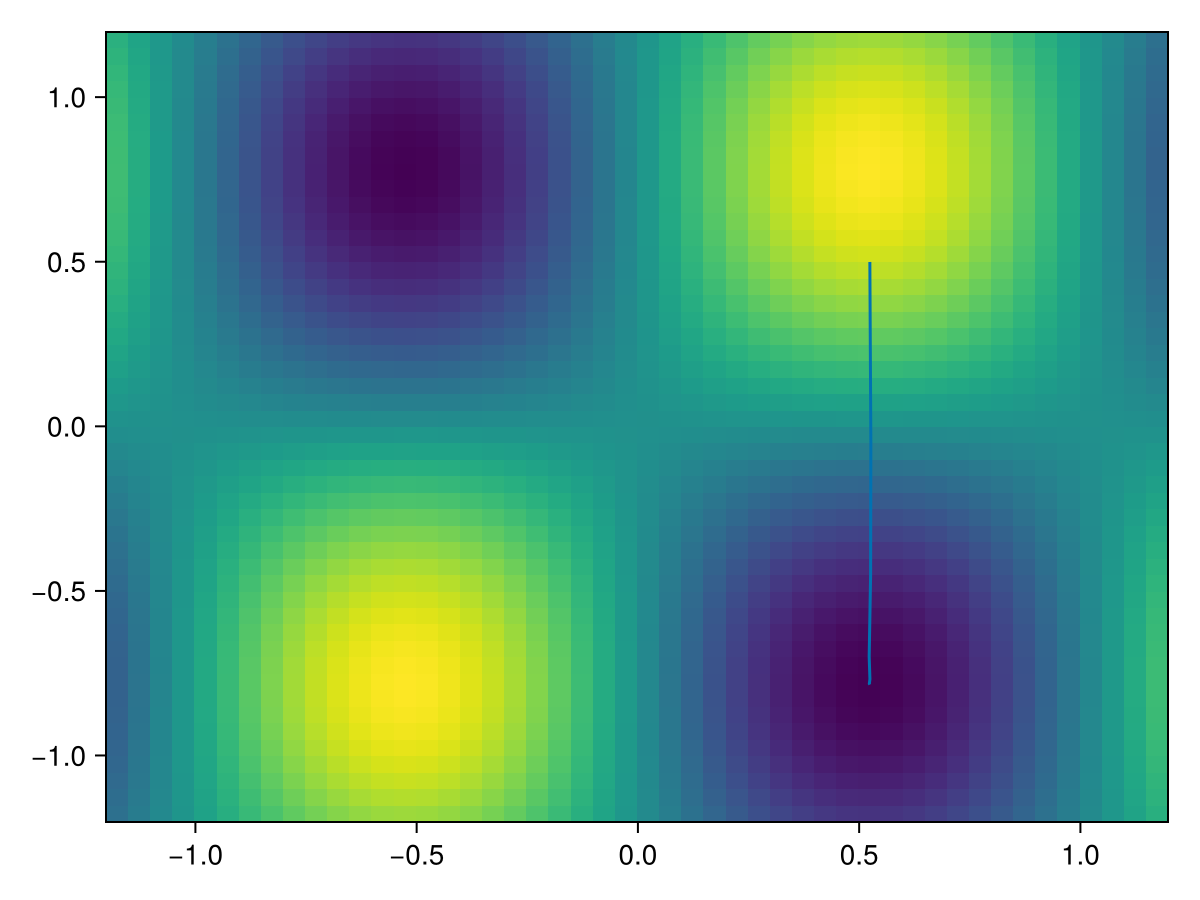

In [6]:
fig = Figure()
ax = Axis(fig[1,1])

heatmap!(ax,x,y,dmap)
lines!(ax,hcat(path...)[1,:],hcat(path...)[2,:])
fig

In [7]:
using LinearAlgebra

In [123]:
function test(v::Vector{DT}) where DT
    2*tanh(4*v[1]-1)-1
end

function loss(in::Vector{DT}, res::Vector{Variable{DT}}) where DT
    sum((res .- test(in)).^2)
end

model = Model([Linear(1,10),Tanh(),Linear(10,1)])

trackLoss = []

for epoch in 1:3
    x0 = rand(1000)

    for x in x0
        result = forward(model, [x])
        lossRes = loss([x], result)
        
        push!(trackLoss,lossRes)

        MiniAutoDiff.diff(lossRes)

        update(model, GradientDescent(0.1))
    end
end



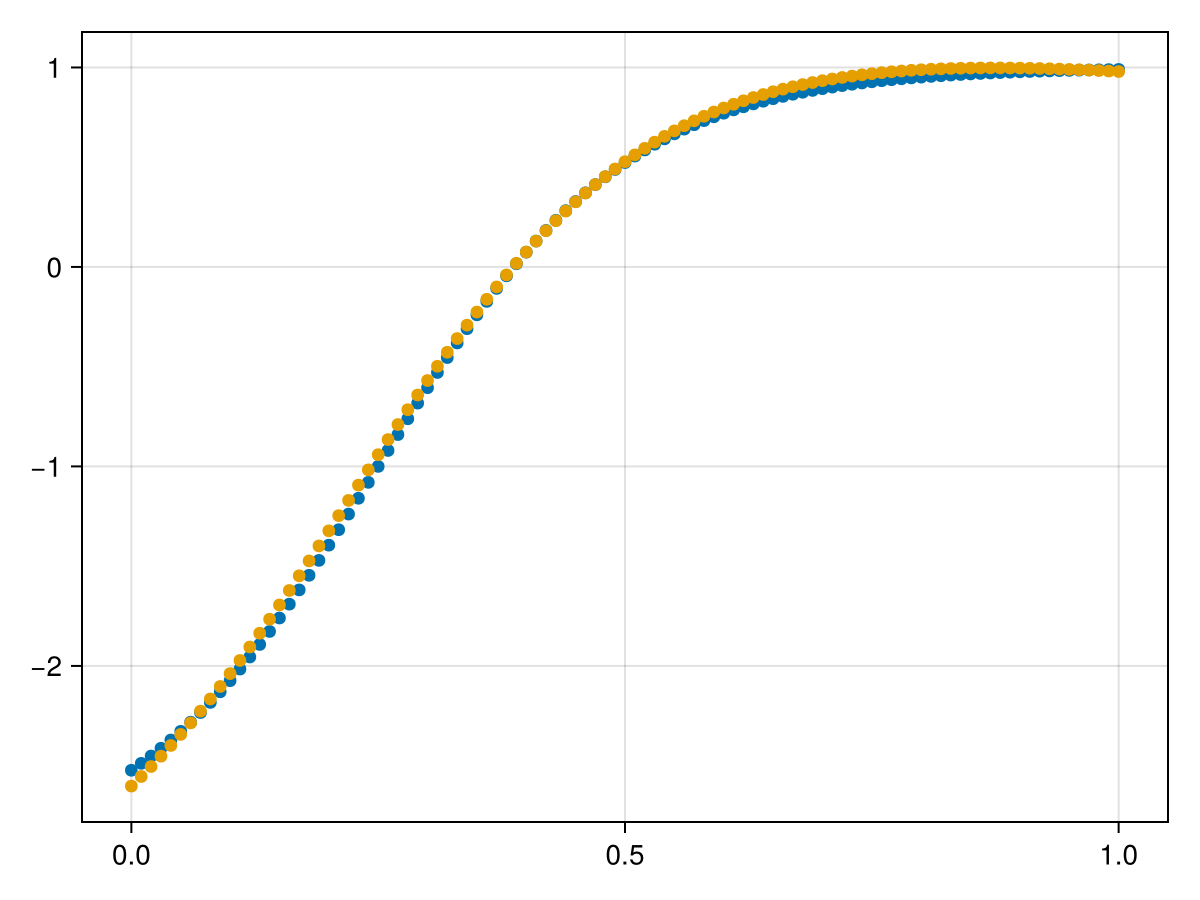

In [124]:

xPlot = 0:0.01:1
yTrue = map(x->test([x]), xPlot)

yModel = map(x->forward(model,[x])[1].value,xPlot)


fig = Figure()
ax = Axis(fig[1,1])

plot!(ax,xPlot,yTrue)
plot!(ax,xPlot,yModel)

fig

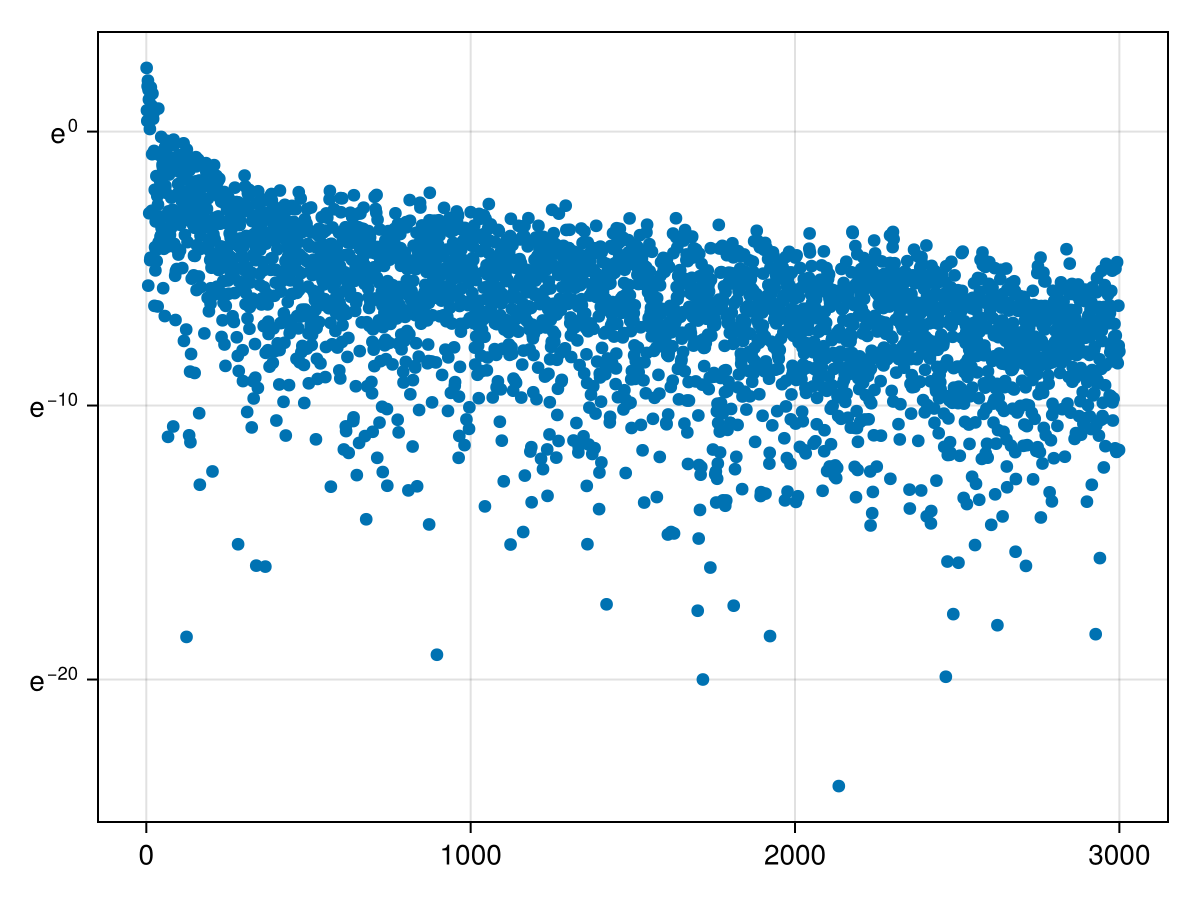

In [125]:
fig = Figure()
ax = Axis(fig[1,1]; yscale =log)
plot!(ax,map(x->x.value,trackLoss))
fig